# Assignment 6: T-SNE

**Objective:**
To determine whether a dataset is suitable for classification and identify potential challenges that may affect model performance 

**Data:**
Dataset obtained from Arabic Handwritten Digits Dataset | Kaggle. Original source unknown. The dataset file is attached below for download. 

**Problem Statement:**
Continuing with your work on a team developing a mobile app for hand calculations in Arabic (begun on Assignment 5), you will now perform a clustering analysis to determine how well you can expect a classification model to work on this data. The app will require a neural network to classify hand-drawn digits in order to correctly complete the calculations. Using clustering, we can determine whether the classes are well separated and identify where a classification model may struggle. Using a dataset of hand-drawn Arabic digits, where each image corresponds to a point in a 784-dimensional space, you are to complete a clustering analysis and visualize the results in a two-dimensional plot.

**Arabic Digits:**
Arabic digits correspond to Roman digits as described in N. Das, A. Mollah, S. Saha, S. Haque, 2010 (https://arxiv.org/abs/1003.1891).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from keras.models import Model
from keras.layers import Input, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA 
import tensorflow.python.util.deprecation as deprecation
from sklearn.manifold import TSNE
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

deprecation._PRINT_DEPRECATION_WARNINGS = False
# Specify random seed for reproducibility
SEED = np.random.seed(2)

Using TensorFlow backend.


## Data

a. Each row of csvImages 10k x 784.csv contains the grayscale values of a 28×28 image. Load this data into a pandas DataFrame and convert it to a NumPy array using pandas.values. Print the shape of the data.


In [2]:
url = "https://raw.githubusercontent.com/Hunteracademic/Unsupervised_assignment_1/master/csvImages_10k_x_784.csv"
Arabic_data = pd.read_csv(url, header=None)
Arabic_data.shape

(10000, 784)

In [3]:
Arabic_array = Arabic_data.values
Arabic_array.shape

(10000, 784)


b. Normalize the values by dividing by 255. To display the images, reshape each array to 28×28 using numpy.ndarray.reshape. Use matplotlib.pyplot.imshow and matplotlib.pyplot.subplot to plot the first five images using the 'gray' colormap.


In [4]:
normalized_data = Arabic_array.astype('float32') / 255.0
normalized_data.reshape(10000, 28, 28)

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

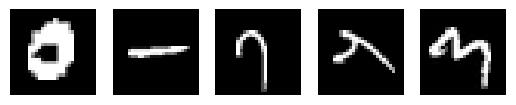

In [5]:
# Plot first 5 images
for i in range(5):
    # Reshape to 28x28
    image = normalized_data[i].reshape(28, 28)
    
    # Create subplot
    plt.subplot(1, 5, i+1)
    plt.imshow(image, cmap='gray')
    plt.axis('off')

plt.show()


c. To prepare the data for input to the neural network, reshape each image back into a one-dimensional array of size 784.


In [6]:
images = normalized_data.reshape((-1, 28 ** 2))
images.shape

(10000, 784)

## Clustering

a. Use sklearn.decomposition.PCA.fit_transform to perform PCA with n_components = 40. This reduces the dimension of each image to a size that is more manageable, while keeping the most important aspects of the data.

In [7]:
pca_model = PCA(n_components=40)
pca_data = pca_model.fit_transform(normalized_data)
pca_model.explained_variance_ratio_.cumsum()

array([0.14481756, 0.21295908, 0.268371  , 0.31903407, 0.36318475,
       0.40078065, 0.4292748 , 0.4541704 , 0.47683364, 0.4973495 ,
       0.51573384, 0.5337144 , 0.5499963 , 0.565382  , 0.57872844,
       0.5915343 , 0.6030091 , 0.61436385, 0.6248899 , 0.63476914,
       0.6440229 , 0.65277094, 0.66113114, 0.6690985 , 0.67689687,
       0.6845401 , 0.69193757, 0.6992407 , 0.7060765 , 0.71267474,
       0.7187748 , 0.7245972 , 0.7301597 , 0.7355372 , 0.7408281 ,
       0.74598515, 0.7508841 , 0.7556717 , 0.76032317, 0.76490104],
      dtype=float32)

## PCA Dimension reduction Verification:
### Before Reduction:

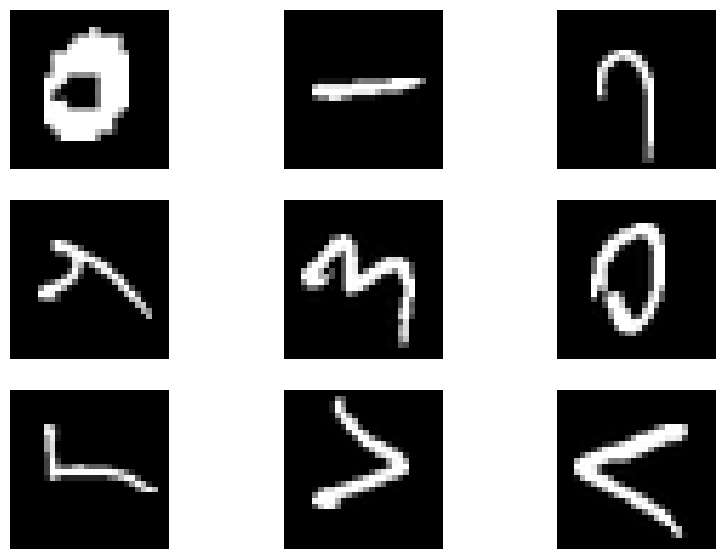

In [8]:
plt.figure(figsize=(10, 7))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    image = normalized_data[i].reshape(28, 28)
    plt.imshow(image, cmap='gray')
    #plt.title(arabic['labels'][i])
    plt.axis('off')
plt.show()

### After Reduction

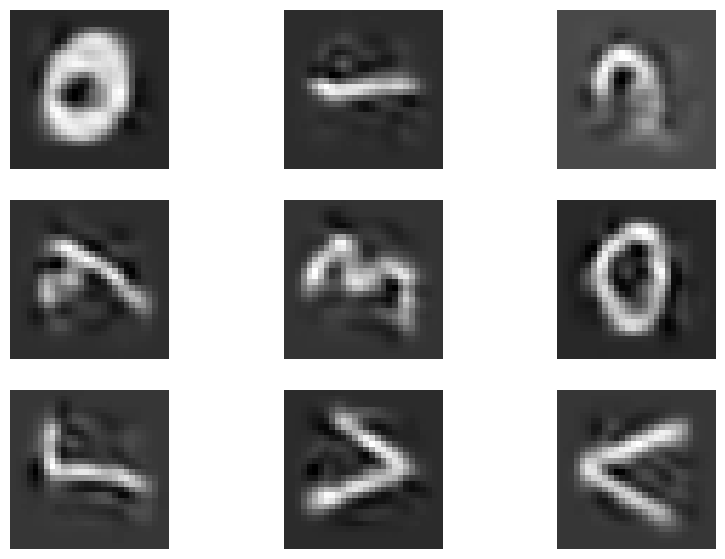

In [9]:
arabic_40comp_vis = pca_model.inverse_transform(pca_data)
arabic_40comp_vis = arabic_40comp_vis.reshape((-1, 28, 28))

plt.figure(figsize=(10, 7))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(arabic_40comp_vis[i], cmap='gray')
    #plt.title(arabic['labels'][i])
    plt.axis('off')
plt.show()

b. Create at least 8 clustering models using K-Means, Hierarchical, and DBSCAN, experimenting with different hyperparameters. 

c. Calculate the silhouette score for each model and tabulate the results.

### K-Means

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

model = KMeans(n_clusters=10, random_state=42)
labels = model.fit_predict(pca_data)
labels = pd.Series(labels)
sil_score = silhouette_score(pca_data, labels)
print(f'Silhouette Score: {sil_score}')

Silhouette Score: 0.12128695100545883


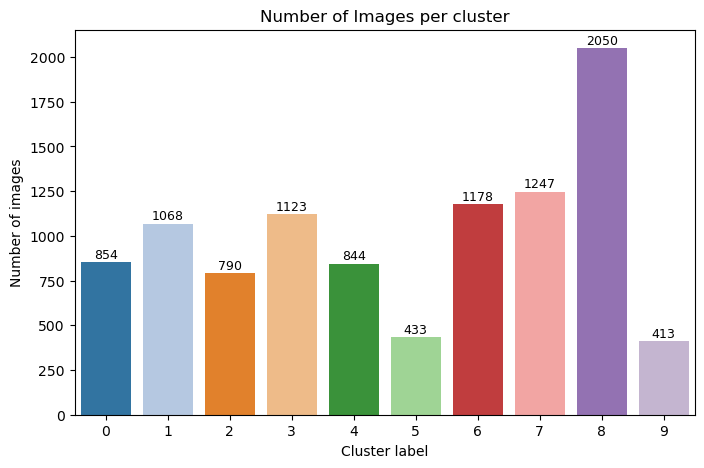

In [11]:
cluster_counts = labels.value_counts().sort_index()
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=cluster_counts.index, 
                 y=cluster_counts.values, 
                 palette='tab20')

for i, value in enumerate(cluster_counts.values):
    ax.text(i, value + 5, str(value), ha='center', va='bottom', fontsize=9)

plt.xlabel('Cluster label')
plt.ylabel('Number of images')
plt.title('Number of Images per cluster')
plt.show()

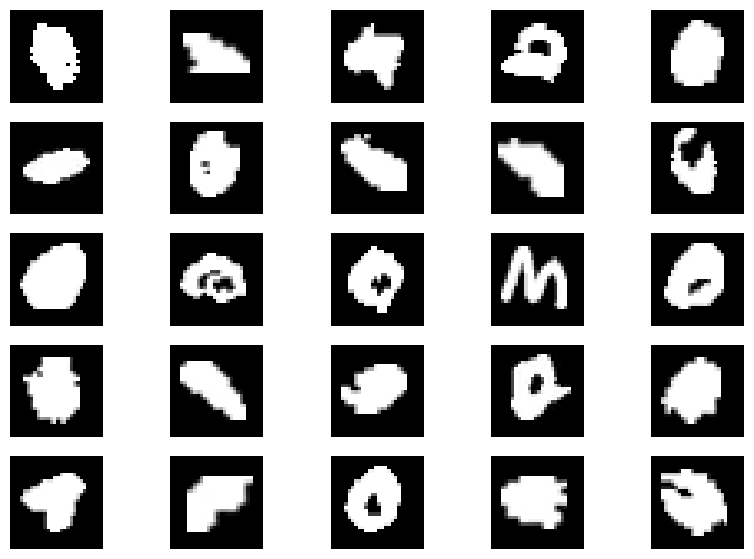

In [12]:
pca_data_df = pd.DataFrame(pca_data, columns=[f'PC{i+1}' for i in range(pca_data.shape[1])])
pca_data_df['Cluster'] = labels

index_list = pd.Series(pca_data_df[pca_data_df['Cluster'] == 5].index)
selected_images = index_list.sample(25).tolist()

normalized_data = Arabic_array.astype('float32') / 255.0
normalized_data.reshape(10000, 28, 28)

plt.figure(figsize=(10, 7))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(normalized_data[selected_images[i]].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.show()

### Mapping the obtained digits (right) to the k-means clusters labels (left)

In [13]:
digits_dictionary_kmeans = {0 : 5,
                            1 : 1,
                            2 : 2,
                            3 : 9,
                            4 : 8,
                            5 : 0,
                            6 : 7,
                            7 : 6,
                            8 : 4,
                            9 : 0
                            }

### DBSCAN

In [14]:
eps_list = [0.5, 1.0, 1.5]
min_samples_list = [5, 10, 15]

dbscan_results = []

for e in eps_list:
    for s in min_samples_list:
        dbscan = DBSCAN(eps=e, min_samples=s)
        labels = dbscan.fit_predict(pca_data)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if n_clusters > 1:
            score = silhouette_score(pca_data, labels)
        else:
            score = None
            
        dbscan_results.append({
            'eps': e,
            'min_samples': s,
            'n_clusters': n_clusters,
            'silhouette_score': score
        })

dbscan_df = pd.DataFrame(dbscan_results)
print(dbscan_df)

   eps  min_samples  n_clusters  silhouette_score
0  0.5            5           2         -0.163431
1  0.5           10           0               NaN
2  0.5           15           0               NaN
3  1.0            5           9         -0.159085
4  1.0           10           6         -0.169061
5  1.0           15           3         -0.143013
6  1.5            5          25         -0.224470
7  1.5           10           2         -0.094630
8  1.5           15           1               NaN


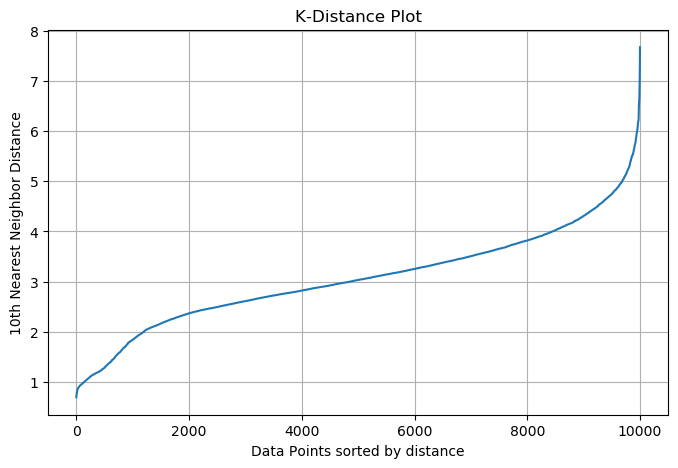

Match Found -> eps: 1.8332, min_samples: 10
Match Found -> eps: 1.9757, min_samples: 10
Match Found -> eps: 2.6879, min_samples: 10
Match Found -> eps: 2.8304, min_samples: 10
Match Found -> eps: 3.1153, min_samples: 10


In [15]:

neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(pca_data)
distances, indices = neighbors_fit.kneighbors(pca_data)
distances = np.sort(distances[:, 9], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title("K-Distance Plot")
plt.xlabel("Data Points sorted by distance")
plt.ylabel("10th Nearest Neighbor Distance")
plt.grid(True)
plt.show()

eps_list = np.linspace(min(distances), max(distances), 50)
min_samples_list = [10, 15, 20, 25]

for e in eps_list:
    for s in min_samples_list:
        dbscan = DBSCAN(eps=e, min_samples=s)
        labels = dbscan.fit_predict(pca_data)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if n_clusters == 10:
            print(f"Match Found -> eps: {e:.4f}, min_samples: {s}")

In [16]:
eps_list = [1.8332, 2.2608, 3.1160]
min_samples_list = [10, 15]

dbscan_results = []

for e in eps_list:
    for s in min_samples_list:
        dbscan = DBSCAN(eps=e, min_samples=s)
        labels = dbscan.fit_predict(pca_data)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if n_clusters > 1:
            score = silhouette_score(pca_data, labels)
        else:
            score = None
            
        dbscan_results.append({
            'eps': e,
            'min_samples': s,
            'n_clusters': n_clusters,
            'silhouette_score': score
        })

dbscan_df = pd.DataFrame(dbscan_results)
print(dbscan_df)

      eps  min_samples  n_clusters  silhouette_score
0  1.8332           10          10         -0.161916
1  1.8332           15           3         -0.101384
2  2.2608           10          19         -0.231947
3  2.2608           15           9         -0.138274
4  3.1160           10          10         -0.055938
5  3.1160           15           5          0.092711


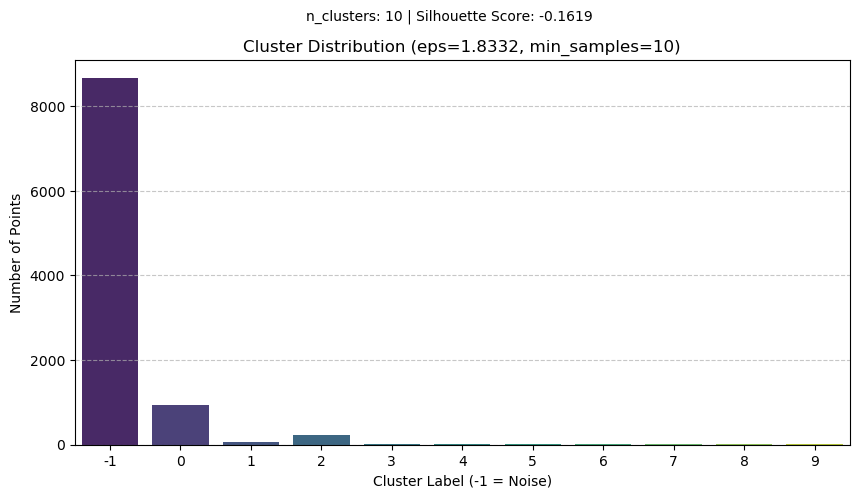

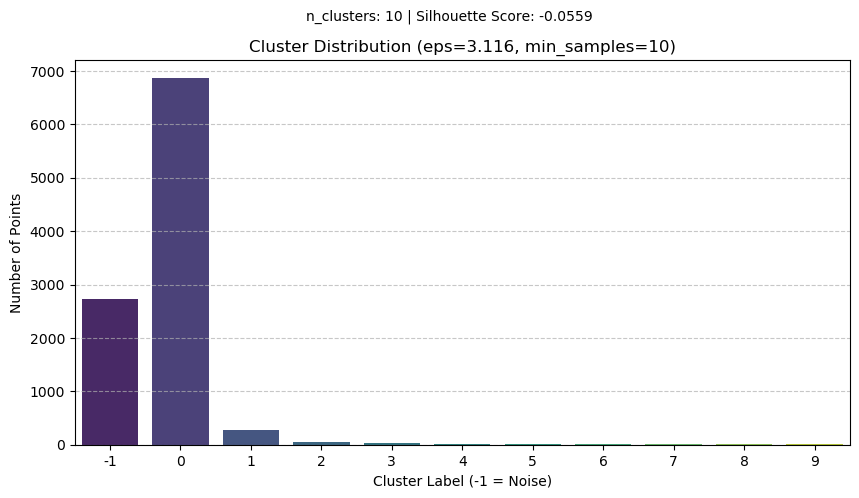

In [17]:
ten_cluster_configs = dbscan_df[dbscan_df['n_clusters'] == 10]
 
for idx, row in ten_cluster_configs.iterrows():
    # Get parameters
    e, s = row['eps'], int(row['min_samples'])
    score = row['silhouette_score']
   
    # Re-run DBSCAN to get labels for plotting
    dbscan = DBSCAN(eps=e, min_samples=s)
    labels = dbscan.fit_predict(pca_data)
   
    # Count points per cluster (including -1 for noise)
    unique, counts = np.unique(labels, return_counts=True)
   
    # Create plot
    plt.figure(figsize=(10, 5))
    sns.barplot(x=unique, y=counts, palette='viridis')
   
    plt.title(f"Cluster Distribution (eps={e}, min_samples={s})")
    plt.suptitle(f"n_clusters: 10 | Silhouette Score: {score:.4f}", fontsize=10)
    plt.xlabel("Cluster Label (-1 = Noise)")
    plt.ylabel("Number of Points")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

### Hierarchical

In [18]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score

# Defining different linkage methods for hierarchical clustering
methods = ['ward', 'single', 'average', 'complete']

In [19]:
# Evaluate different clustering models using silhouette scores - Metric Euclidean
scipy_models_euclidean = {}
for method in methods:
    model = fcluster(linkage(pca_data, method=method, metric='euclidean'), 10, criterion='maxclust')
    sil_score = silhouette_score(pca_data, model, metric="euclidean")
    scipy_models_euclidean[(method, 10)] = (sil_score, model)

# Evaluate different clustering models using silhouette scores - Metric Manhattan
scipy_models_manhattan = {}
for method in methods:
    if method == 'ward':
        continue  # Ward linkage is not defined for Manhattan distance
    model = fcluster(linkage(pca_data, method=method, metric='cityblock'), 10, criterion='maxclust')
    sil_score = silhouette_score(pca_data, model, metric="manhattan")
    scipy_models_manhattan[(method, 10)] = (sil_score, model)


# Removing cluster labels from the dictionary for DataFrame creation
restructured_scipy_models_euclidean = {k: v[0] for k, v in scipy_models_euclidean.items()}
# Creating DataFrame for Euclidean results
scipy_dfs_models_euclidean = pd.DataFrame.from_dict(restructured_scipy_models_euclidean, orient='index', columns=['Silhouette Score'])
scipy_dfs_models_euclidean.index = pd.MultiIndex.from_tuples(scipy_dfs_models_euclidean.index, names=['Method', 'n_clusters'])
scipy_dfs_models_euclidean.reset_index(inplace=True)
scipy_dfs_models_euclidean.pivot(index='n_clusters', columns='Method', values='Silhouette Score')

# Creaeting DataFrame for Manhattan results
restructured_scipy_models_manhattan = {k: v[0] for k, v in scipy_models_manhattan.items()}
scipy_dfs_models_manhattan = pd.DataFrame.from_dict(restructured_scipy_models_manhattan, orient='index', columns=['Silhouette Score'])
scipy_dfs_models_manhattan.index = pd.MultiIndex.from_tuples(scipy_dfs_models_manhattan.index, names=['Method', 'n_clusters'])
scipy_dfs_models_manhattan.reset_index(inplace=True)
scipy_dfs_models_manhattan.pivot(index='n_clusters', columns='Method', values='Silhouette Score')

# Joining both DataFrames for comparison
scipy_dfs_combined = scipy_dfs_models_euclidean.merge(
    scipy_dfs_models_manhattan,
    how='left',
    on=['Method', 'n_clusters'],
    suffixes=('_euclidean', '_manhattan')
)
scipy_dfs_combined.pivot(index='n_clusters', columns='Method', values=['Silhouette Score_euclidean', 'Silhouette Score_manhattan'])
#scipy_dfs_combined[(scipy_dfs_combined['n_clusters'] == 5) | (scipy_dfs_combined['n_clusters'] == 3) | (scipy_dfs_combined['n_clusters'] == 4)].sort_values(by='Silhouette Score_euclidean', ascending=False)
scipy_dfs_combined

,Method,n_clusters,Silhouette Score_euclidean,Silhouette Score_manhattan
0,ward,10,0.096949,NaN
1,single,10,0.081751,0.060120
2,average,10,0.144421,0.138429
3,complete,10,0.087601,0.043804


### Dendograms

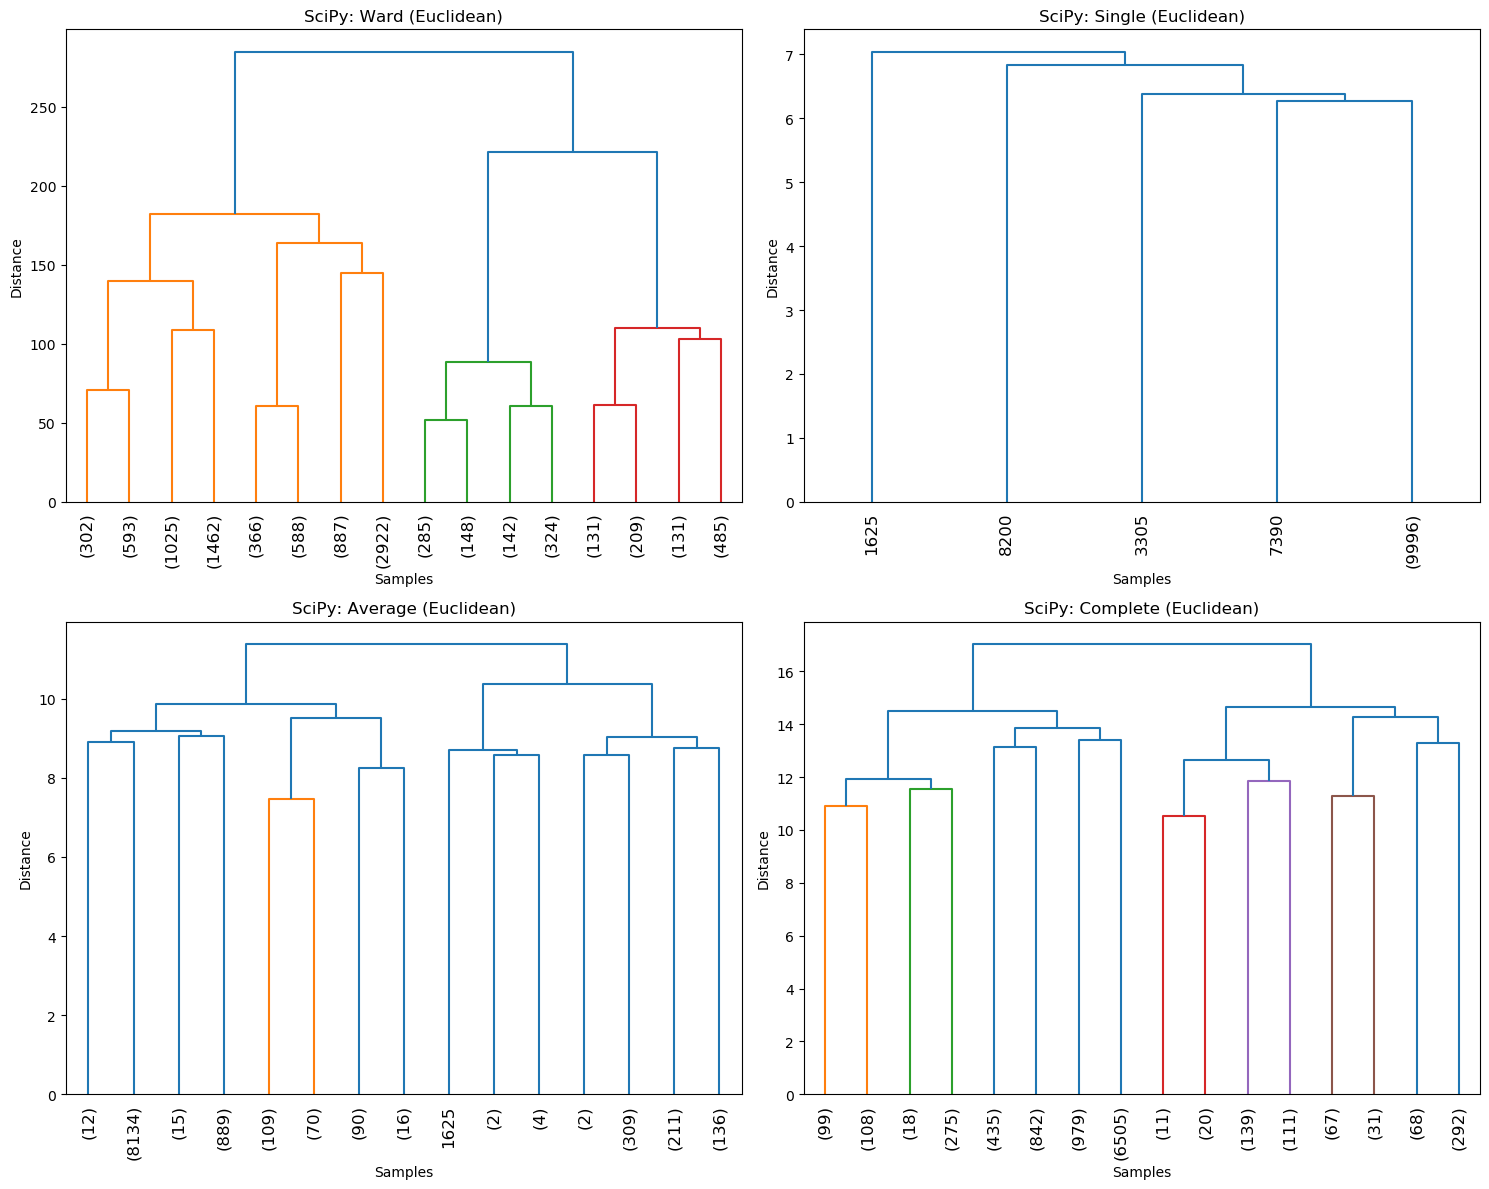

In [20]:
# SciPy Euclidean dendrograms
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, method in enumerate(methods):
    Z = linkage(pca_data, method=method, metric='euclidean')
    dendrogram(Z, ax=axes[i], truncate_mode='level', p=3, leaf_rotation=90)
    axes[i].set_title(f'SciPy: {method.capitalize()} (Euclidean)')
    axes[i].set_xlabel('Samples')
    axes[i].set_ylabel('Distance')

plt.tight_layout()
plt.show()

### Cluster Distribution

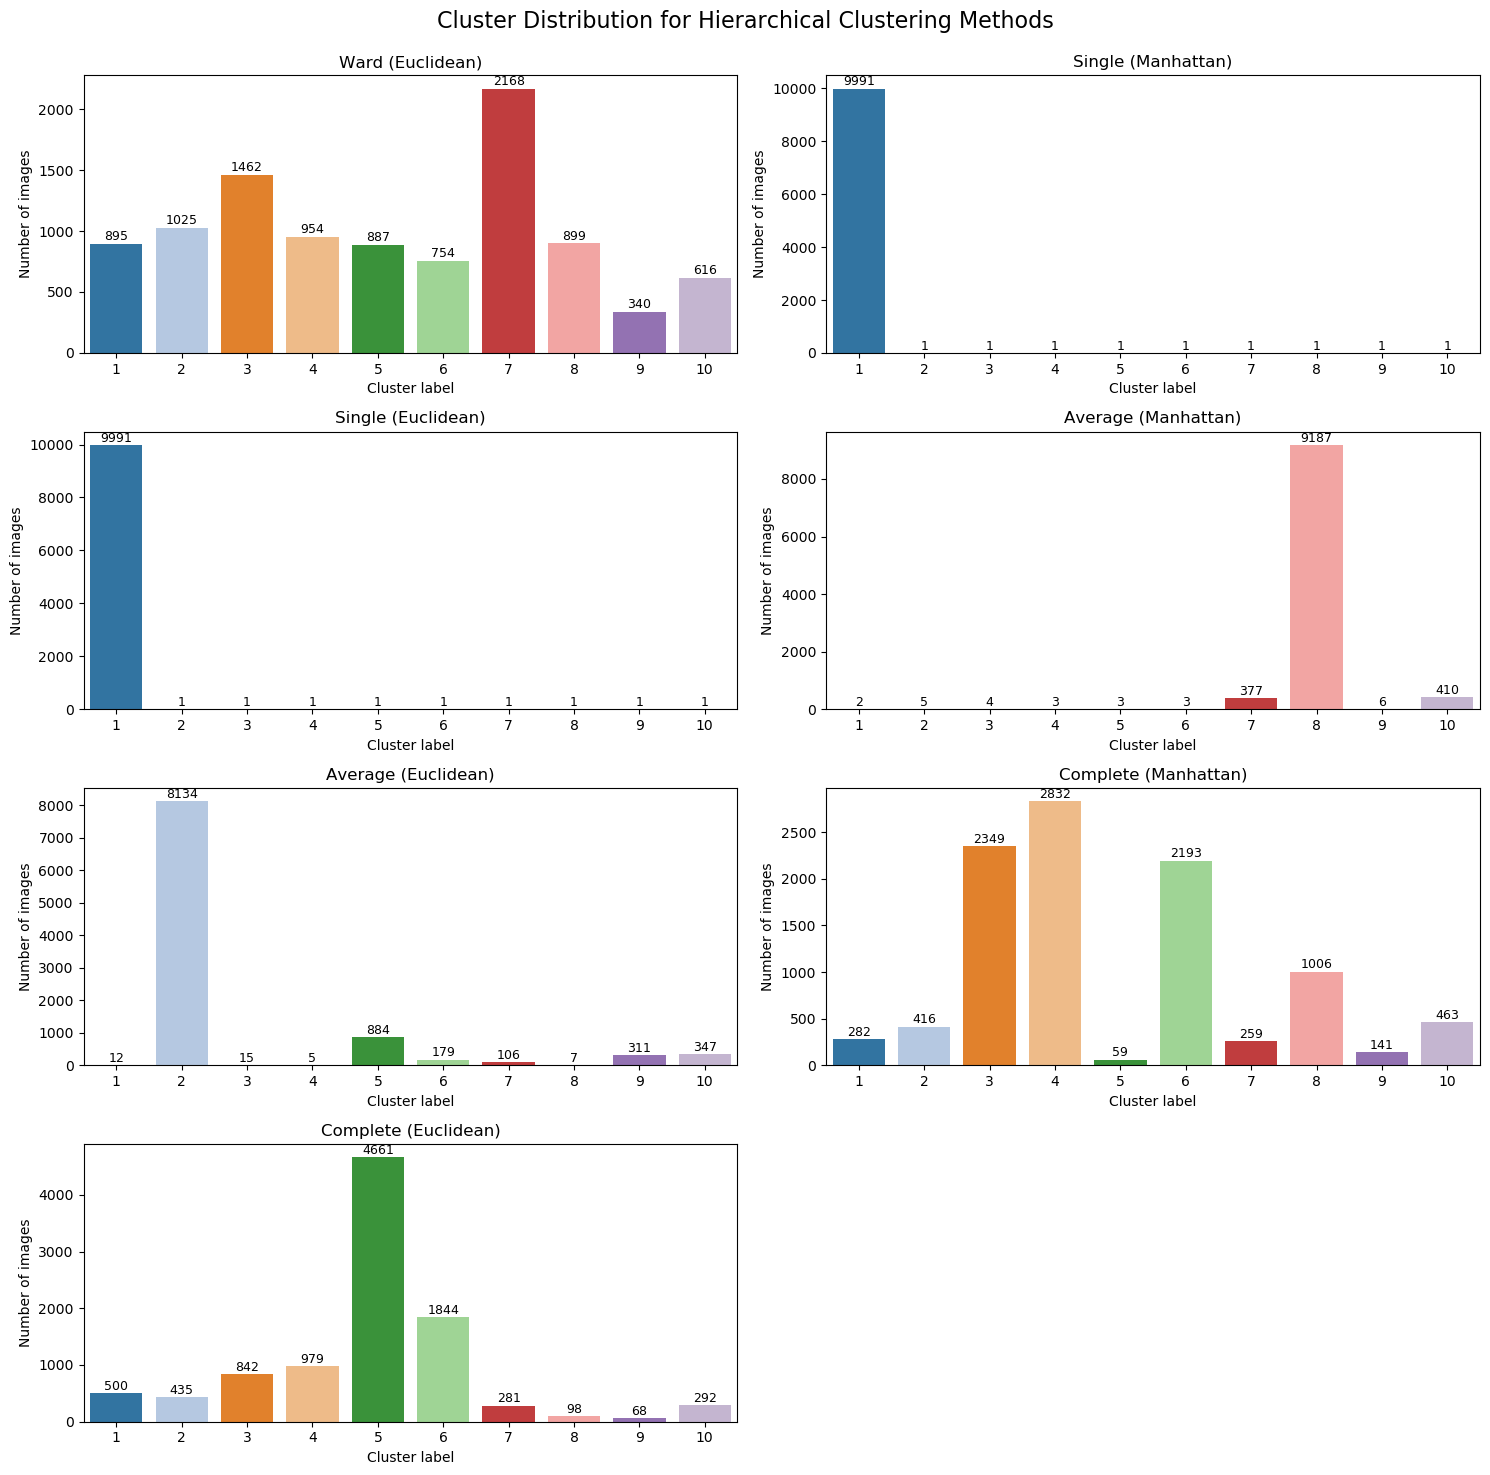

In [21]:
fig, ax = plt.subplots(4, 2, figsize=(15, 15))

for i, method in enumerate(methods):
    labels = pd.Series(scipy_models_euclidean[(method, 10)][1])
    cluster_counts = labels.value_counts().sort_index()

    sns.barplot(
        x=cluster_counts.index,
        y=cluster_counts.values,
        palette='tab20',
        ax=ax[i, 0]
    )

    for j, value in enumerate(cluster_counts.values):
        ax[i, 0].text(j, value + 5, str(value), ha='center', va='bottom', fontsize=9)

    ax[i, 0].set_xlabel('Cluster label')
    ax[i, 0].set_ylabel('Number of images')
    ax[i, 0].set_title(f'{method.capitalize()} (Euclidean)')
    plt.tight_layout()

methods_manhattan = [m for m in methods if m != 'ward']  # Exclude 'ward' for Manhattan
for i, method in enumerate(methods_manhattan):  # Drop 'ward' for Manhattan since it's not applicable
    labels = pd.Series(scipy_models_manhattan[(method, 10)][1])
    cluster_counts = labels.value_counts().sort_index()

    sns.barplot(
        x=cluster_counts.index,
        y=cluster_counts.values,
        palette='tab20',
        ax=ax[i, 1]
    )

    for j, value in enumerate(cluster_counts.values):
        ax[i, 1].text(j, value + 5, str(value), ha='center', va='bottom', fontsize=9)

    ax[i, 1].set_xlabel('Cluster label')
    ax[i, 1].set_ylabel('Number of images')
    ax[i, 1].set_title(f'{method.capitalize()} (Manhattan)')
    plt.tight_layout()

ax[3, 1].axis('off')  # Hide the empty subplot
fig.suptitle('Cluster Distribution for Hierarchical Clustering Methods', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

d. Select the best model for this use case and justify your choice in Markdown.

After a detailed analysis of different clustering algorithms, we made some observations regarding the results we got for each one:
### K-means:
With K set to 10 being the only reasonable cluster set the model performed ok. It gave reasonable demographics with a subpar silhouette score. Because there are so few hyperparameters to tune in K-Means we are stuck with this result on the model. Overall the model ran into certain problems that are naturally occurring in the dataset, digits like 3 and 4 being so similar and having two separate clusters for 0 make it not the best model over all.
### DBSCAN:
As seen in the graphs, even after using the ideal hyperparameters to tune our DBSCAN model, we are still ending up with a very poor cluster distribution. The model seems to struggle with the specific density of our dataset, as it either classifies the vast majority of the points as noise or dumps everything into one cluster while creating 9 other tiny clusters consisting of isolated noise nodes
### Hierachical Clustering (Selected Model):
In terms of looking for a balance between cluster distribution, decent silhouette scores and after iterating over some t-SNE visuals, using agglomerative clustering with the **ward** method, 10 clusters and a **euclidean** distance was our best option. This model, just like k-means, also ran into the same classification difficulties due to the nature of the dataset, resulting in 2 clusters mapping to the digit 0 as well as not being able to differentiate 3 and 4 very well. We picked this model because of the clear visualizations we obtained after running t-SNE and the clear separation we obtained for some of the digits.

In [22]:
labels = pd.Series(scipy_models_euclidean[('ward', 10)][1]) # Using the best distribution
pca_data_df = pd.DataFrame(pca_data, columns=[f'PC{i+1}' for i in range(pca_data.shape[1])])
pca_data_df['Cluster'] = labels

### Dictionary Mapping Explanation
In order to obtain what digit did each one of the clusters represents, we created a code that randomly selects 25 images from a given cluster, and plots them on a square grid. We ran this cell for different clusters and identified the digit that appeared the most on each one. The relationship between cluster label and digit was defined in the dictionary right after visualization (Note that clusters 9 and 10 map to the same digit 0). We identified that the digits 3 and 4 were overlapping in the same cluster and that is going to be shown when we run cluster visualization below.


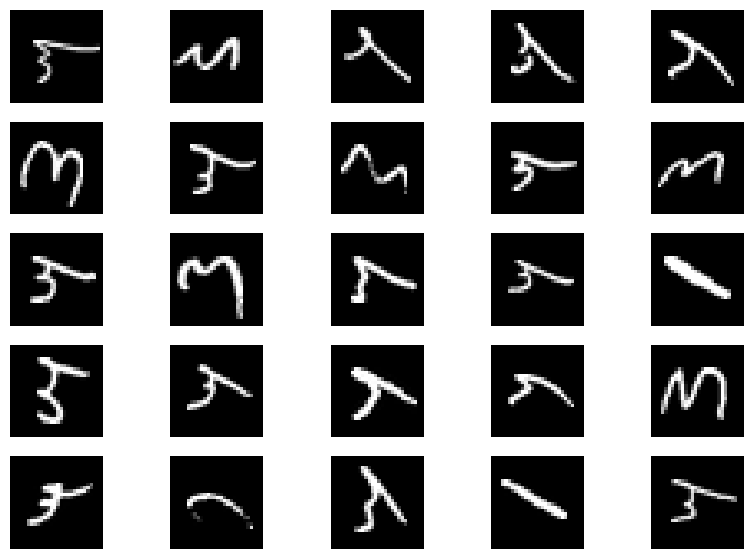

In [23]:
index_list = pd.Series(pca_data_df[pca_data_df['Cluster'] == 7].index)
selected_images = index_list.sample(25).tolist()

normalized_data = Arabic_array.astype('float32') / 255.0
normalized_data.reshape(10000, 28, 28)

plt.figure(figsize=(10, 7))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(normalized_data[selected_images[i]].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.show()

### Mapping the obtained digits (right) to the agglomerative cluster labels (left)

In [24]:
digits_dictionary_agg = {1 : 8,
                        2 : 9,
                        3 : 6,
                        4 : 1,
                        5 : 7,
                        6 : 2,
                        8 : 5,
                        7 : 4,
                        9 : 0,
                        10 : 0}

# Mapping cluster labels to digit labels
pca_data_df['Digit'] = pca_data_df['Cluster'].map(digits_dictionary_agg)

## t-SNE

a. Use sklearn.manifold.TSNE to perform dimensional reduction on the dataset using t-SNE with n_components = 2. Try at least 8 different runs using different choices for perplexity, n_iter, and metric.

posx and posy should be finite values
posx and posy should be finite values


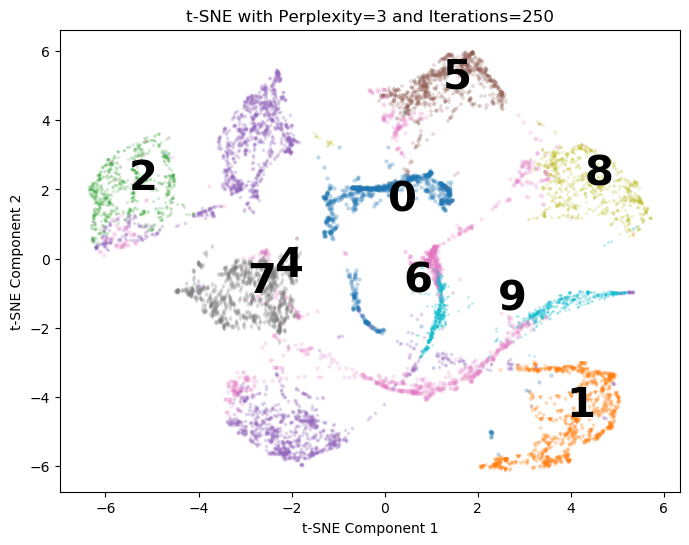

posx and posy should be finite values
posx and posy should be finite values


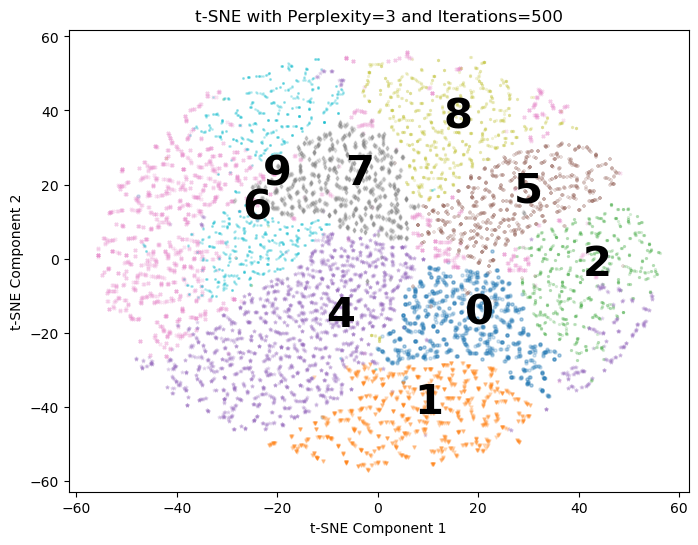

posx and posy should be finite values
posx and posy should be finite values


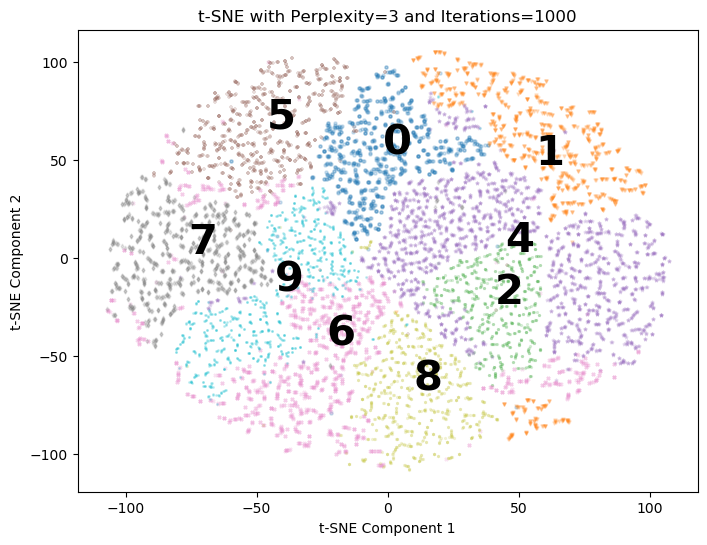

posx and posy should be finite values
posx and posy should be finite values


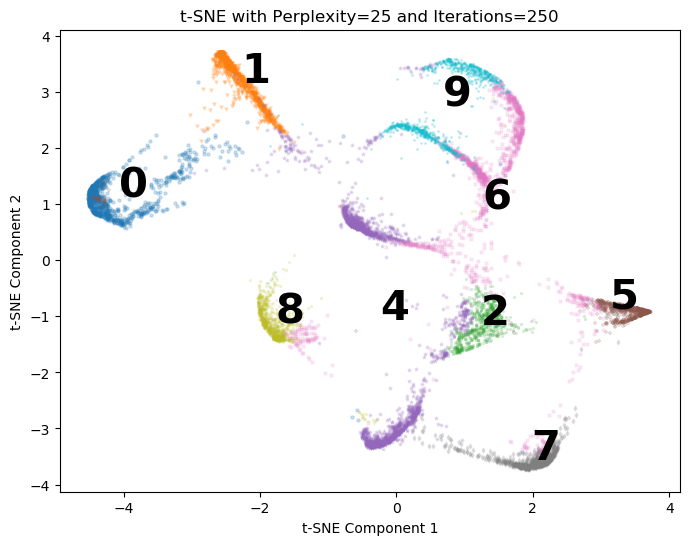

posx and posy should be finite values
posx and posy should be finite values


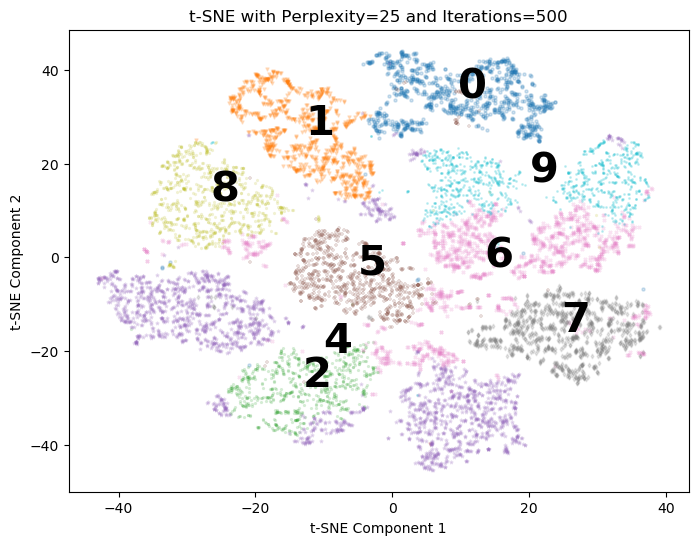

posx and posy should be finite values
posx and posy should be finite values


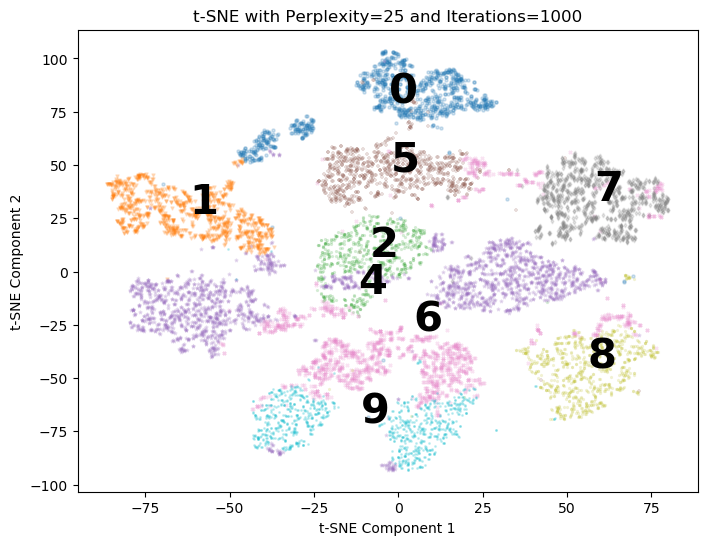

posx and posy should be finite values
posx and posy should be finite values


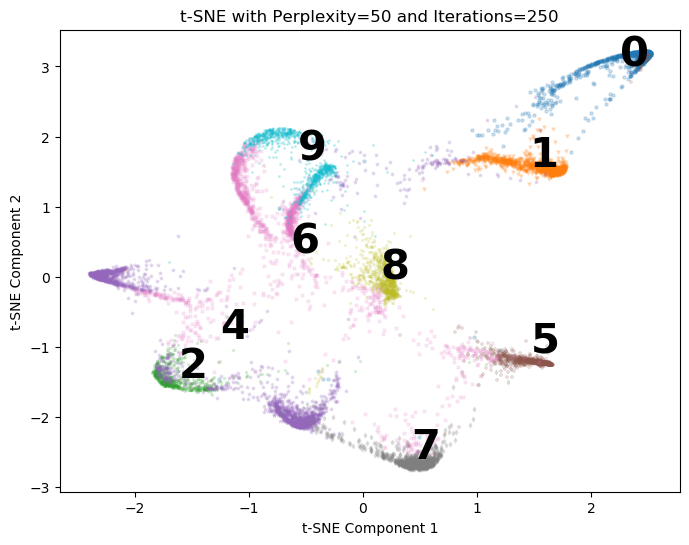

posx and posy should be finite values
posx and posy should be finite values


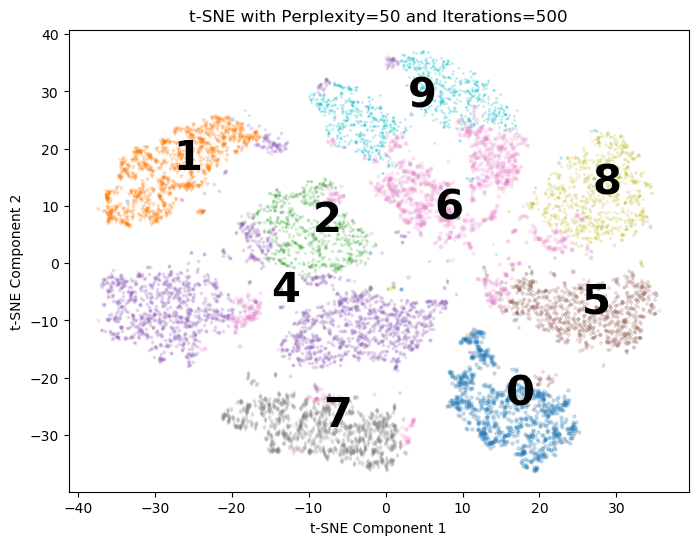

posx and posy should be finite values
posx and posy should be finite values


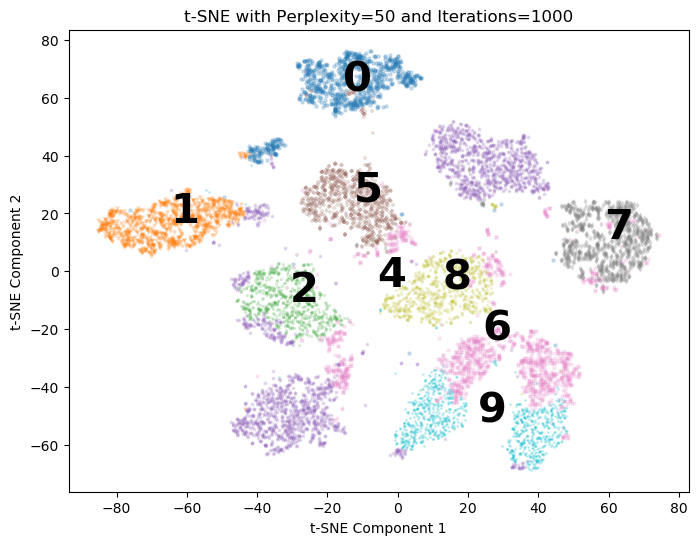

In [27]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)


MARKER = ['o', 'v', '1', 'p' ,'*', '+', 'x', 'd', '4', '.']
for perp in [3, 25, 50]:
    for iterations in [250, 500, 1000]:
        model_tsne = TSNE(random_state=SEED, verbose=0, n_components=2, 
                          perplexity=perp, n_iter=iterations)
        tsne_data = model_tsne.fit_transform(pca_data)
        plt.figure(figsize=(8, 6))
        plt.title(f't-SNE with Perplexity={perp} and Iterations={iterations}')
        plt.xlabel('t-SNE Component 1')
        plt.ylabel('t-SNE Component 2')
        for i in range(10):
            selections = tsne_data[pca_data_df['Digit'] == i]
            plt.scatter(selections[:,0], selections[:,1], alpha=0.2, marker=MARKER[i], s=5)
            x, y = selections.mean(axis=0)
            plt.text(x, y, str(i), fontdict={'weight': 'bold', 'size': 30})    

        plt.show()

d. In Markdown, explain which plot provides the best visualization. You may revisit the clustering models in step 2 to improve your results.

Our last graph for T-SNE is the best with perplexity at 50 with iterations at 1000. This provides pretty good separation between clusters. Notable overlaps would be clusters 6 and 9. Cluster 4 also shows high dispersion across the plot. This is because the model had trouble differentiating between the digits 3 and 4 making it look as though there are two different clusters in one. We also noted that digits like 1,2,7 and 8 are well-separated from other clusters, which alings to one of the observations we made when getting random samples of the clusters they belong to: These digits are consistent after several runs of the image sampling cell for each cluster.

## Conclusions

a. Display your best t-SNE plot of your best model and restate the hyperparameter choices.

posx and posy should be finite values
posx and posy should be finite values


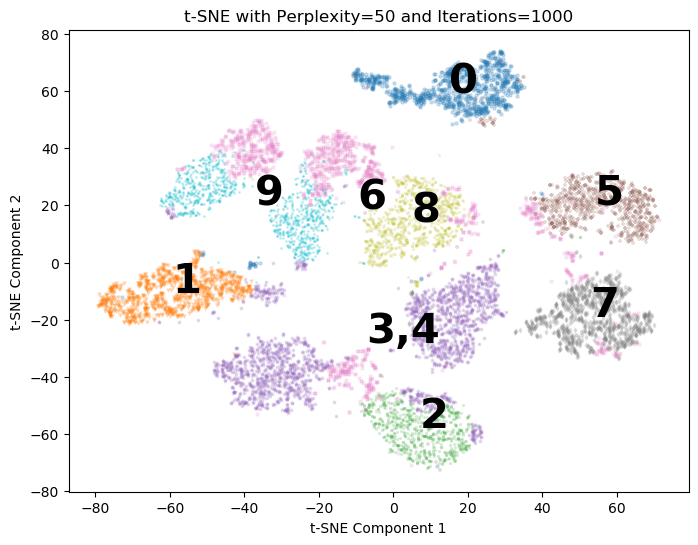

In [ ]:
model_tsne = TSNE(random_state=SEED, verbose=0, n_components=2, 
                    perplexity=50, n_iter=1000)
tsne_data = model_tsne.fit_transform(pca_data)
plt.figure(figsize=(8, 6))
plt.title(f't-SNE with Perplexity={perp} and Iterations={iterations}')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
for i in range(10):
    selections = tsne_data[pca_data_df['Digit'] == i]
    plt.scatter(selections[:,0], selections[:,1], alpha=0.2, marker=MARKER[i], s=5)
    x, y = selections.mean(axis=0)
    plt.text(x, y, ('3,4' if i == 4 else str(i)), fontdict={'weight': 'bold', 'size': 30})    
plt.show()

b. In Markdown, discuss how well suited this dataset is for classification. Identify any digit classes that may be confused by a classification model.

The Arabic Handwritten Digits dataset is moderately suited for classification, as clustering reveals some well-separated groups but significant overlaps in the t-SNE and PCA visualizations, indicating inherent variability in handwriting styles that challenges model boundaries.

Specific digits that our model had trouble deciphering were as follows:

| Problem Definition| Number 1 | Number 2|
| :---------------- | :------: | ----: |
| Both can be written as a circle |   0   | 5 |
| Have the same shape just rotated |   7   | 8 |
| Digits can be written with a similar 3 shape |  3   | 4 |
| When the right angle is sloppy on the 6 it looks like an 8 |  6   | 8 |



c. In Markdown, explain why using PCA-reduced data is preferred over the original high-dimensional data as input for clustering and t-SNE visualization in some cases, and describe how to determine whether PCA-reduced data is appropriate to use and, if so, how to decide on the number of principal components to retain.

To understand why PCA-reduced data is preferable to high-dimensional data we need to understand the *"curse of dimensionality"* where distances become less meaningful, noise dominates, and computational costs explode. PCA mitigates this by projecting data into a lower-dimensional space that captures the most variance, retaining key signals while discarding irrelevant noise.This reduction can improve clustering algorithms like K-means or DBSCAN by making them more stable and faster.

PCA-reduced data is appropriate when the data has linear relationships or high redundancy of features.The goal is to reduce noise, simplify datasets, and improve model computation efficiencies. Running PCA and reducing the dimensionality of data can effectively achieve these goals.

When choosing to use PCA it's commonplace to plot the cumulative **explained variance ratio**. The **explained variance ratio** contains the proportion of total variance explained by each principal component, where each value is an eigenvalue divided by the sum of all eigenvalues. The cumulative sum of the explained variance gives a ratio that lets you select the smallest number of components while tracking the amount of variance captured in percent value. 

## Contributions
**Daniel:**

I explored the Agglomerative model, trying different hyperparameters, explored the cluster-digits correspondance, wrote the code for image sampling, added the t-SNE hyperparameter exploration code and analyzed the obtained results with the best visualization with my teammates.

**Hunter:**

I ran K-Means model, gave first pass through answering T-sne best results and answered conclusion questions b and c.

**Alex:**

I did the first part (porting the code from our last assignment), and worked on the DBSCAN model. Otherwise I contributed to the final model selection and summary